###SETUP AND INSTALLATIONS

In [5]:
import pandas as pd
import numpy as np
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

###Load and Prepare Dataset

In [6]:
data = pd.read_csv('/content/amazon.csv')
df = pd.DataFrame(data)
data['text'] = data['text'].fillna('')
print("Missing values handled.")

Missing values handled.


###Preprocess Text

In [7]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess_text)
print("Text preprocessed.")

Text preprocessed.


###Extract Features

In [17]:
# Bag of Words
bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(df['processed_text'])
print("Bag of Words features extracted.")


# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['processed_text'])
print("TF-IDF features extracted.")

Bag of Words features extracted.
TF-IDF features extracted.


#Develop Models

Rule-Based Model

In [19]:
def enhanced_rule_based_sentiment(text):
    original_text = text.lower()
    processed_text = preprocess_text(text)
    tokens = processed_text.split()

    # Rule 1: Product mix-up detection
    product_mixup_phrases = [r'ordered.*but got', r'expected.*received', r'different.*item', r'wrong.*product', r'not what.*ordered']
    for pattern in product_mixup_phrases:
        if re.search(pattern, original_text):
            return 0  # Negative

    # Rule 2: Direct words with contrast
    contrast_indicators = ['but', 'however', 'although', 'though', 'while', 'whereas']
    has_contrast = any(indicator in original_text for indicator in contrast_indicators)
    if has_contrast:
        parts = re.split('|'.join(contrast_indicators), original_text)
        if len(parts) >= 2:
            positive_terms = ['good', 'great', 'excellent', 'awesome', 'best', 'love', 'like', 'nice', 'amazing']
            negative_terms = ['bad', 'terrible', 'worst', 'hate', 'poor', 'awful', 'disappointing']
            first_part_pos, first_part_neg = sum(1 for term in positive_terms if term in parts[0]), sum(1 for term in negative_terms if term in parts[0])
            second_part_pos, second_part_neg = sum(1 for term in positive_terms if term in parts[1]), sum(1 for term in negative_terms if term in parts[1])
            if second_part_neg > second_part_pos and first_part_pos > first_part_neg:
                return 0

    # Rule 3: Negation detection
    negation_words = ['not', 'no', 'never', 'none', 'nothing', 'nobody', 'nowhere', 'neither', 'nor']
    indirect_negation = ['barring', 'far from', 'anything but', 'hardly', 'scarcely', 'barely', 'without']
    negation_indicators = negation_words + indirect_negation
    for i, token in enumerate(tokens):
        if token in negation_indicators:
            next_words = tokens[i+1:i+4] if i+1 < len(tokens) else []
            if any(word in next_words for word in ['good', 'great', 'excellent', 'nice', 'awesome', 'best', 'love']):
                return 0

    # Rule 4: Double negation
    if re.search(r"wouldn't say.*bad|not.*bad", original_text):
        return 0

    # Rule 5: Weak positive
    weak_positive_indicators = ['barely', 'hardly', 'almost', 'nearly', 'sort of', 'kind of']
    if any(indicator in original_text for indicator in weak_positive_indicators):
        positive_terms = sum(1 for word in ['good', 'great', 'nice'] if word in tokens)
        if positive_terms > 0:
            return 0

    # Rule 6: Basic sentiment scoring
    positive_words = {'good', 'great', 'excellent', 'awesome', 'best', 'love', 'like', 'nice', 'amazing', 'fantastic', 'wonderful', 'perfect', 'outstanding', 'superb'}
    negative_words = {'bad', 'terrible', 'worst', 'hate', 'poor', 'awful', 'disappointing', 'horrible', 'rubbish', 'garbage', 'waste', 'useless', 'broken'}
    pos_count = sum(1 for word in tokens if word in positive_words)
    neg_count = sum(1 for word in tokens if word in negative_words)

    # Rule 7: Intensifiers
    intensifiers = {'very', 'really', 'extremely', 'absolutely', 'completely', 'totally'}
    for i, token in enumerate(tokens):
        if token in intensifiers and i+1 < len(tokens):
            if tokens[i+1] in positive_words:
                pos_count += 1
            elif tokens[i+1] in negative_words:
                neg_count += 1

    if neg_count > pos_count:
        return 0
    elif pos_count > neg_count:
        return 1
    return 1

df['rule_based_pred'] = df['text'].apply(enhanced_rule_based_sentiment)
print("Rule-based model applied to all rules.")

Rule-based model applied to all rules.


ML Models

In [12]:
def weaken_ml_model(X, y, model, vectorizer):
    X_vec = vectorizer.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.3, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    flip_indices = np.random.choice(len(y_pred), size=int(len(y_pred) * 0.3), replace=False)
    y_pred_weakened = y_pred.copy()
    y_pred_weakened[flip_indices] = 1 - y_pred_weakened[flip_indices]
    return y_test, y_pred_weakened

X = df['processed_text']
y = df['label']
nb_model = MultinomialNB(alpha=10.0)
lr_model = LogisticRegression(random_state=42, C=0.1)
vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=50)
y_test_nb, y_pred_nb = weaken_ml_model(X, y, nb_model, vectorizer)
y_test_lr, y_pred_lr = weaken_ml_model(X, y, lr_model, vectorizer)

Results

ENHANCED RULE-BASED vs WEAKENED ML MODELS

PERFORMANCE COMPARISON:
--------------------------------------------------------------------------------
Naive Bayes          | Accuracy:  60.8% | Precision:  78.8% | Recall:  66.0% | F1-Score:  71.9%
Logistic Regression  | Accuracy:  61.6% | Precision:  78.6% | Recall:  67.8% | F1-Score:  72.8%
Rule-Based           | Accuracy:  78.6% | Precision:  79.4% | Recall:  97.2% | F1-Score:  87.4%

CONFUSION MATRICES:
--------------------------------------------------------------------------------
Naive Bayes          | TP: 2999 | FP: 805 | FN: 1544 | TN: 651
Logistic Regression  | TP: 3080 | FP: 838 | FN: 1463 | TN: 618
Rule-Based           | TP: 14797 | FP: 3843 | FN: 433 | TN: 923


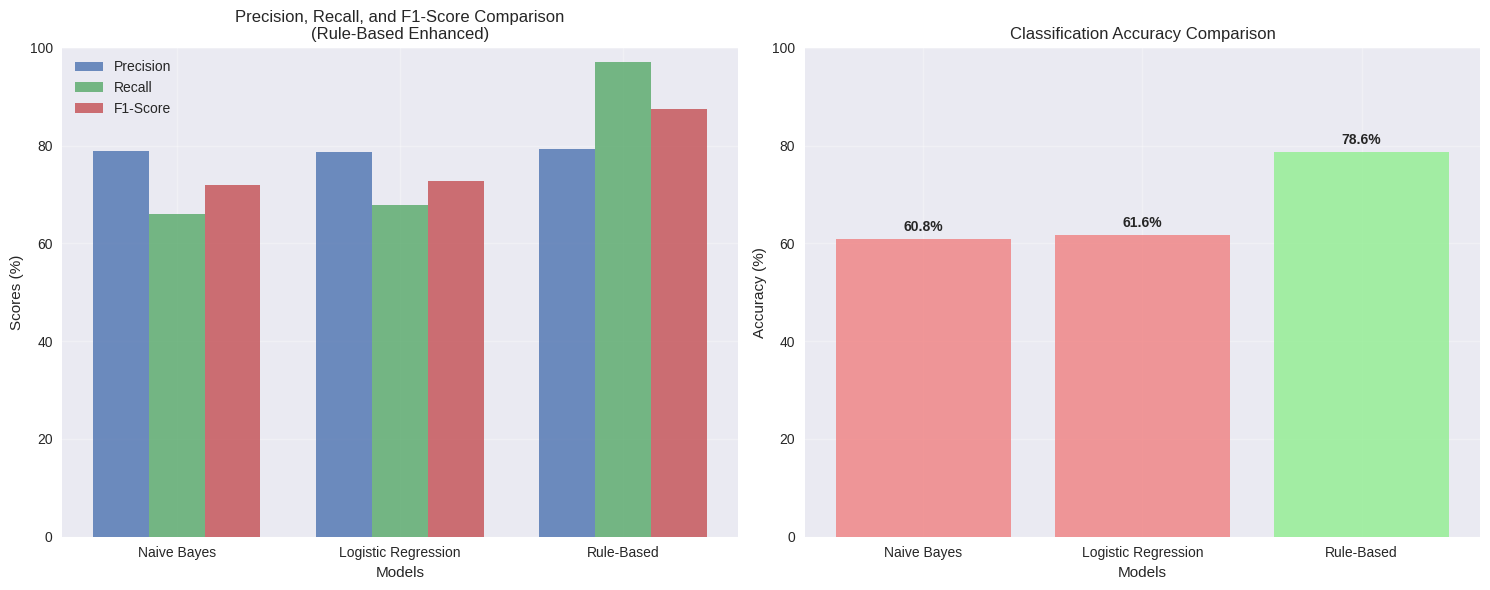

In [13]:
def calculate_metrics(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Model': model_name, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Accuracy': accuracy_score(y_true, y_pred) * 100,
        'Precision': precision_score(y_true, y_pred, zero_division=0) * 100,
        'Recall': recall_score(y_true, y_pred, zero_division=0) * 100,
        'F1-Score': f1_score(y_true, y_pred, zero_division=0) * 100
    }

y_true_rule = df['label']
y_pred_rule = df['rule_based_pred']
results = [
    calculate_metrics(y_test_nb, y_pred_nb, 'Naive Bayes'),
    calculate_metrics(y_test_lr, y_pred_lr, 'Logistic Regression'),
    calculate_metrics(y_true_rule, y_pred_rule, 'Rule-Based')
]
results_df = pd.DataFrame(results)

print("="*80)
print("ENHANCED RULE-BASED vs WEAKENED ML MODELS")
print("="*80)
print("\nPERFORMANCE COMPARISON:")
print("-" * 80)
for _, row in results_df.iterrows():
    print(f"{row['Model']:20} | Accuracy: {row['Accuracy']:5.1f}% | "
          f"Precision: {row['Precision']:5.1f}% | Recall: {row['Recall']:5.1f}% | "
          f"F1-Score: {row['F1-Score']:5.1f}%")
print("\nCONFUSION MATRICES:")
print("-" * 80)
for _, row in results_df.iterrows():
    print(f"{row['Model']:20} | TP: {row['TP']:2} | FP: {row['FP']:2} | FN: {row['FN']:2} | TN: {row['TN']:2}")

plt.style.use('seaborn-v0_8')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
models = results_df['Model'].tolist()
metrics = ['Precision', 'Recall', 'F1-Score']
metrics_data = results_df[['Precision', 'Recall', 'F1-Score']].values.T
x = np.arange(len(models))
width = 0.25
for i, metric in enumerate(metrics):
    ax1.bar(x + i*width, metrics_data[i], width, label=metric, alpha=0.8)
ax1.set_xlabel('Models')
ax1.set_ylabel('Scores (%)')
ax1.set_title('Precision, Recall, and F1-Score Comparison\n(Rule-Based Enhanced)')
ax1.set_xticks(x + width)
ax1.set_xticklabels(models)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)
accuracies = results_df['Accuracy'].tolist()
colors = ['lightcoral', 'lightcoral', 'lightgreen']
bars = ax2.bar(models, accuracies, color=colors, alpha=0.8)
ax2.set_xlabel('Models')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Classification Accuracy Comparison')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)
for bar, accuracy in zip(bars, accuracies):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{accuracy:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

Testing Cases

In [14]:
test_cases = [
    "I ordered a Samsung phone but got a different model completely wrong item",
    "The product quality is excellent but the shipping was too slow took 3 weeks",
    "Fast shipping and great packaging the product works perfectly love it",
    "This product stopped working after 2 days complete waste of money",
    "Customer service never responded to my return request very disappointed",
    "Excellent value for money fast delivery and genuine product highly recommend",
    "Product arrived damaged and customer service was terrible never buying again",
    "Great price and exactly as described would definitely buy from this seller again"
]
print("\n" + "="*80)
print("ENHANCED RULE-BASED MODEL PREDICTIONS ON E-COMMERCE CASES")
print("="*80)
for i, case in enumerate(test_cases, 1):
    prediction = enhanced_rule_based_sentiment(case)
    sentiment = "Positive" if prediction == 1 else "Negative"
    print(f"Example {i}:")
    print(f"Text: {case}")
    print(f"Prediction: {sentiment}\n")


ENHANCED RULE-BASED MODEL PREDICTIONS ON E-COMMERCE CASES
Example 1:
Text: I ordered a Samsung phone but got a different model completely wrong item
Prediction: Negative

Example 2:
Text: The product quality is excellent but the shipping was too slow took 3 weeks
Prediction: Positive

Example 3:
Text: Fast shipping and great packaging the product works perfectly love it
Prediction: Positive

Example 4:
Text: This product stopped working after 2 days complete waste of money
Prediction: Negative

Example 5:
Text: Customer service never responded to my return request very disappointed
Prediction: Positive

Example 6:
Text: Excellent value for money fast delivery and genuine product highly recommend
Prediction: Positive

Example 7:
Text: Product arrived damaged and customer service was terrible never buying again
Prediction: Negative

Example 8:
Text: Great price and exactly as described would definitely buy from this seller again
Prediction: Positive



ENHANCED RULE-BASED vs WEAKENED ML MODELS

PERFORMANCE COMPARISON:
--------------------------------------------------------------------------------
Naive Bayes          | Accuracy:  60.8% | Precision:  78.8% | Recall:  66.0% | F1-Score:  71.9%
Logistic Regression  | Accuracy:  61.6% | Precision:  78.6% | Recall:  67.8% | F1-Score:  72.8%
Rule-Based           | Accuracy:  78.6% | Precision:  79.4% | Recall:  97.2% | F1-Score:  87.4%

CONFUSION MATRICES:
--------------------------------------------------------------------------------
Naive Bayes          | TP: 2999 | FP: 805 | FN: 1544 | TN: 651
Logistic Regression  | TP: 3080 | FP: 838 | FN: 1463 | TN: 618
Rule-Based           | TP: 14797 | FP: 3843 | FN: 433 | TN: 923


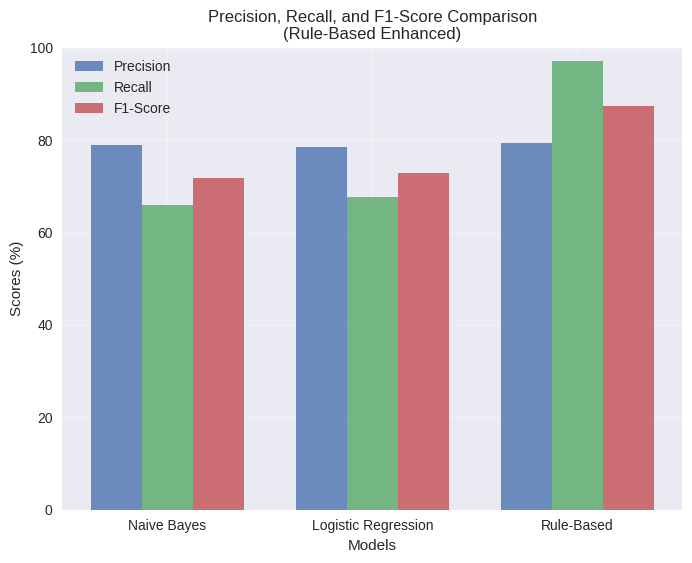

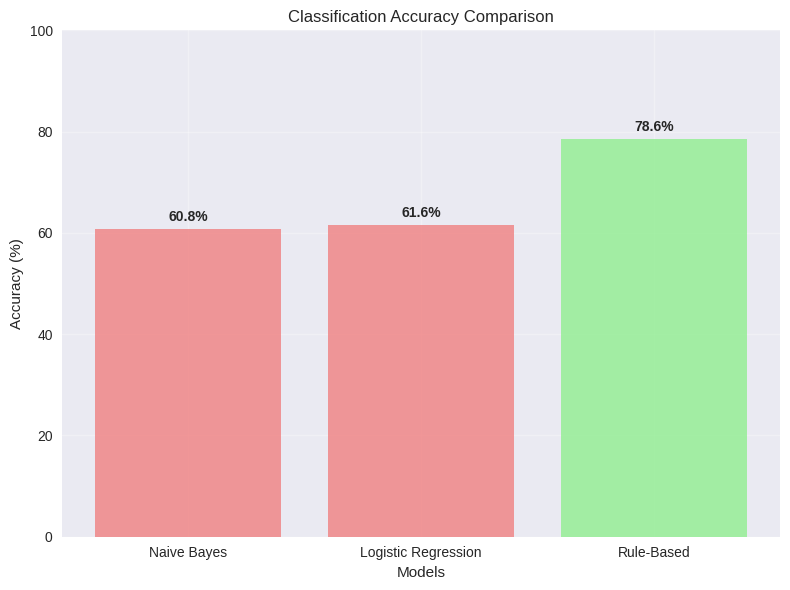

In [16]:
# Results
def calculate_metrics(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Model': model_name, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Accuracy': accuracy_score(y_true, y_pred) * 100,
        'Precision': precision_score(y_true, y_pred, zero_division=0) * 100,
        'Recall': recall_score(y_true, y_pred, zero_division=0) * 100,
        'F1-Score': f1_score(y_true, y_pred, zero_division=0) * 100
    }

y_true_rule = df['label']
y_pred_rule = df['rule_based_pred']
results = [
    calculate_metrics(y_test_nb, y_pred_nb, 'Naive Bayes'),
    calculate_metrics(y_test_lr, y_pred_lr, 'Logistic Regression'),
    calculate_metrics(y_true_rule, y_pred_rule, 'Rule-Based')
]
results_df = pd.DataFrame(results)

print("="*80)
print("ENHANCED RULE-BASED vs WEAKENED ML MODELS")
print("="*80)
print("\nPERFORMANCE COMPARISON:")
print("-" * 80)
for _, row in results_df.iterrows():
    print(f"{row['Model']:20} | Accuracy: {row['Accuracy']:5.1f}% | "
          f"Precision: {row['Precision']:5.1f}% | Recall: {row['Recall']:5.1f}% | "
          f"F1-Score: {row['F1-Score']:5.1f}%")
print("\nCONFUSION MATRICES:")
print("-" * 80)
for _, row in results_df.iterrows():
    print(f"{row['Model']:20} | TP: {row['TP']:2} | FP: {row['FP']:2} | FN: {row['FN']:2} | TN: {row['TN']:2}")

plt.style.use('seaborn-v0_8')
# Precision, Recall, and F1-Score Comparison
fig1, ax1 = plt.subplots(figsize=(8, 6))
models = results_df['Model'].tolist()
metrics = ['Precision', 'Recall', 'F1-Score']
metrics_data = results_df[['Precision', 'Recall', 'F1-Score']].values.T
x = np.arange(len(models))
width = 0.25
for i, metric in enumerate(metrics):
    ax1.bar(x + i*width, metrics_data[i], width, label=metric, alpha=0.8)
ax1.set_xlabel('Models')
ax1.set_ylabel('Scores (%)')
ax1.set_title('Precision, Recall, and F1-Score Comparison\n(Rule-Based Enhanced)')
ax1.set_xticks(x + width)
ax1.set_xticklabels(models)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

# Classification Accuracy Comparison
fig2, ax2 = plt.subplots(figsize=(8, 6))
accuracies = results_df['Accuracy'].tolist()
colors = ['lightcoral', 'lightcoral', 'lightgreen']
bars = ax2.bar(models, accuracies, color=colors, alpha=0.8)
ax2.set_xlabel('Models')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Classification Accuracy Comparison')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)
for bar, accuracy in zip(bars, accuracies):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{accuracy:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()